# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [87]:
STUDENT_NAME = "Phan Võ Bảo Trâm"  # TODO: Họ và tên
STUDENT_ID = "2413576"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phan Võ Bảo Trâm (2413576)


In [88]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\HP\Desktop\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [89]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [90]:
# TODO N1
row_max = np.max(logits, axis = 1, keepdims = True)

shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims = True)

predicted_classes = np.argmax(class_probabilities, axis = 1)

confidence_scores = np.max(class_probabilities, axis = 1)

In [91]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [92]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [93]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)

train_feature_std = np.std(X_train, axis = 0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std

X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [94]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [95]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [96]:
# TODO N3
correct_mask = predicted_classes == true_labels

high_confidence_mask = confidence_scores >= confidence_threshold

review_mask = (~correct_mask) | (~high_confidence_mask)

review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [97]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [98]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = normalized_batch[:, :, ::-1, :].copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports với các thông tin kèm theo (symboling, normalized_losses, make, ...).
2. Ký hiệu missing value trong CSV là `?`.
3. Cột `symboling` thể hiện mức đánh giá rủi ro bảo hiểm của mẫu xe, có giá trị [-3; 3].

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [99]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)

raw_shape = raw_df.shape

raw_missing_marker_count = (raw_df == '?').values.sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [100]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [101]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors = "coerce")

missing_by_column = df_clean.isna().sum()

print(missing_by_column[missing_by_column>0])

normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
- Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi numeric columns mang ý nghĩa khác nhau, đơn vị đo khác nhau, giá trị phân bố cũng khác nhau, nếu fill bằng cùng một giá trị thì giá trị đó có thể trở thành giá trị ngoại lai, khiến mô hình dự đoán sai lệch.
- Với `price`, lựa chọn drop là phù hợp cho bài EDA này vì số lượng missing value của `price` là 4, rất ít, nên việc loại bỏ chúng không gây ảnh hưởng lớn đến kích thước tổng thể của bộ dữ liệu.
- `normalized_losses` bị khuyết 41 dòng (nhiều nhất trong bộ dữ liệu) nên nếu ta chọn drop hay fill sẽ gây ảnh hưởng lớn đến bộ dữ liệu. Nếu drop sẽ làm mất thông tin của các đặc trưng khác trên cùng dòng đó, khiến kích thước tập dữ liệu bị thu hẹp đáng kể. Nếu fill bằng giá trị trung bình có thể sẽ khiến mô hình dự đoán sai lệch.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [102]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [103]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()

X_auto = analysis_df.to_numpy(dtype=np.float64)

auto_feature_mean = np.mean(X_auto, axis = 0)

auto_feature_std = np.std(X_auto, axis = 0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [104]:
# TODO D4
price_index = AUTO_FEATURES.index("price")

price_z = X_auto_scaled[:, price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [105]:
# TODO D5
engine_idx = AUTO_FEATURES.index("engine_size")
price_idx = AUTO_FEATURES.index("price")

engine_col = X_auto[:, engine_idx]
price_col = X_auto[:, price_idx]

engine_price_corr = np.corrcoef(engine_col, price_col)[0, 1]

price_by_body_style = (df_clean.groupby("body_style")["price"].mean().sort_index())

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

1. **Câu hỏi**: phân phối `price` của ô tô tập trung chủ yếu ở phân khúc nào và có bị lệch không?
2. **Biểu đồ phù hợp**: histogram/KDE

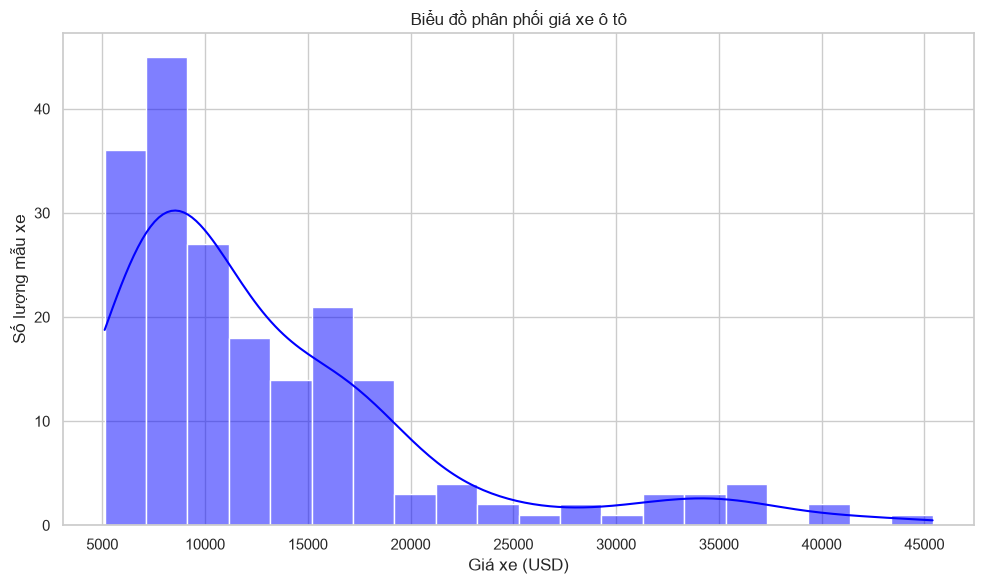

In [106]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10,6))

sns.histplot(data=df_clean, x="price", kde=True, color="blue", bins=20)

plt.title("Biểu đồ phân phối giá xe ô tô")
plt.xlabel("Giá xe (USD)")
plt.ylabel("Số lượng mẫu xe")

plt.tight_layout()
plt.show()

**Nhận xét:** 
`price` có phân phối không đều và bị lệch phải, phần lớn các mẫu xe tập trung ở phân khúc từ 5000 USD đến 15000 USD.

## M2.2 Dataset có cân bằng theo body style không?

1. **Câu hỏi**: Số lượng xe thuộc các `body_style` có sự chênh lệch như thế nào?
2. **Biểu đồ phù hợp**: countplot.

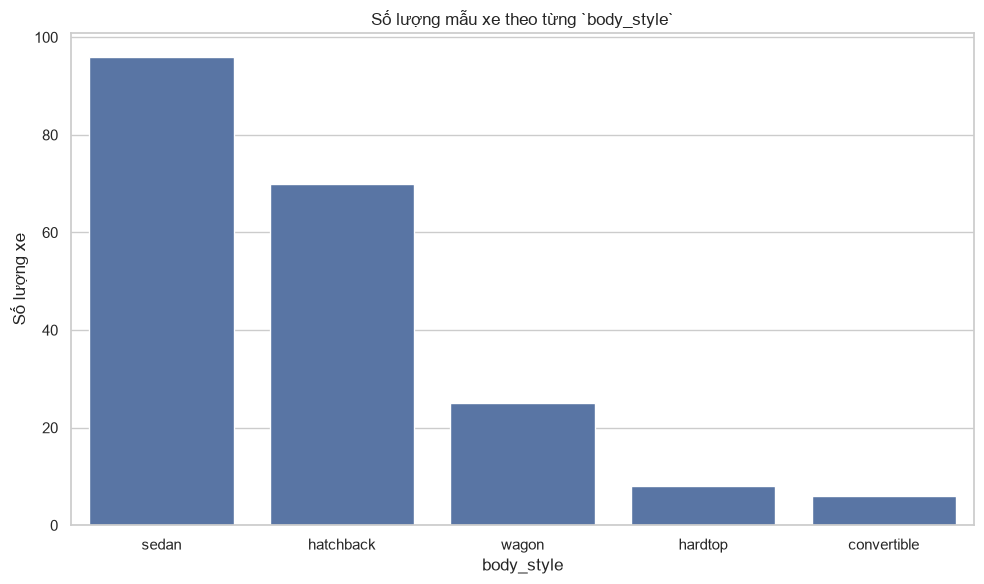

In [107]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10,6))

sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index)

plt.title("Số lượng mẫu xe theo từng `body_style`")
plt.xlabel("body_style")
plt.ylabel("Số lượng xe")

plt.tight_layout()
plt.show()

**Nhận xét:** 
bộ dữ liệu có sự mất cân bằng giữa các `body_style`. 2 style: `sedan` và `hatchback` chiếm số lượng lớn.

## M2.3 Price khác nhau theo body style ra sao?

1. **Câu hỏi**: `body_style` ảnh hưởng đến `price` như thế nào?
2. **Biểu đồ phù hợp**: boxplot.

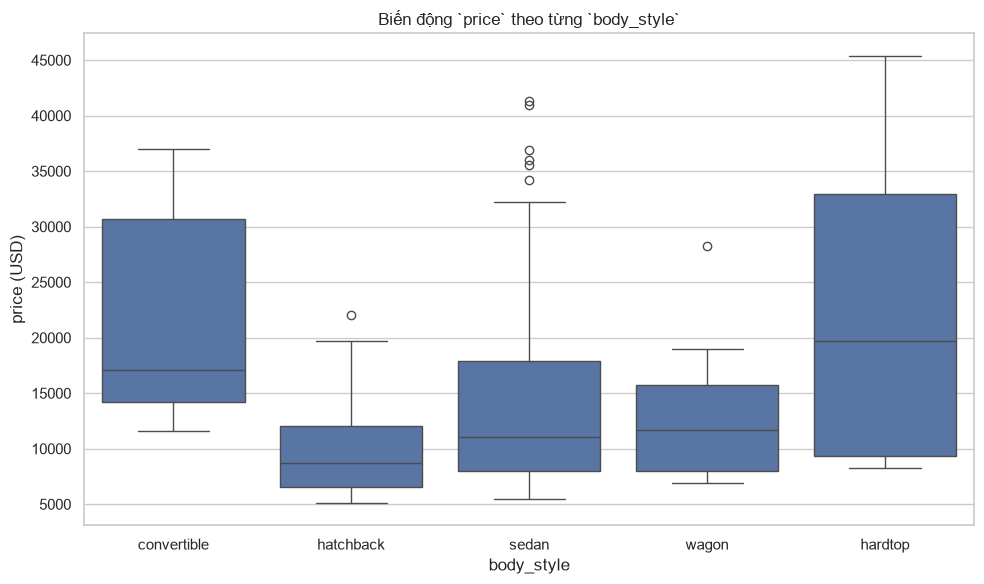

In [108]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean, x="body_style", y="price")

plt.title("Biến động `price` theo từng `body_style`")
plt.xlabel("body_style")
plt.ylabel("price (USD)")

plt.tight_layout()
plt.show()

**Nhận xét:** `hardtop` có median cao nhất bộ dữ liệu (gần 20000 USD) và thân box kéo dài cho thấy mức độ biến động `price` lớn. `hatchback` và `wagon` có thân box hẹp và ít outier cho thấy `price` của 2 dòng này ít biến động. `sedan` có thân box không quá dài nhưng có nhiều outliers cho thấy dòng xe này có `price` biến động mạnh mẽ.

## M2.4 Engine size liên quan thế nào tới price?

1. **Câu hỏi**: mối quan hệ giữa `engine_size` và `price`?
2. **Biểu đồ phù hợp**: scatterplot.

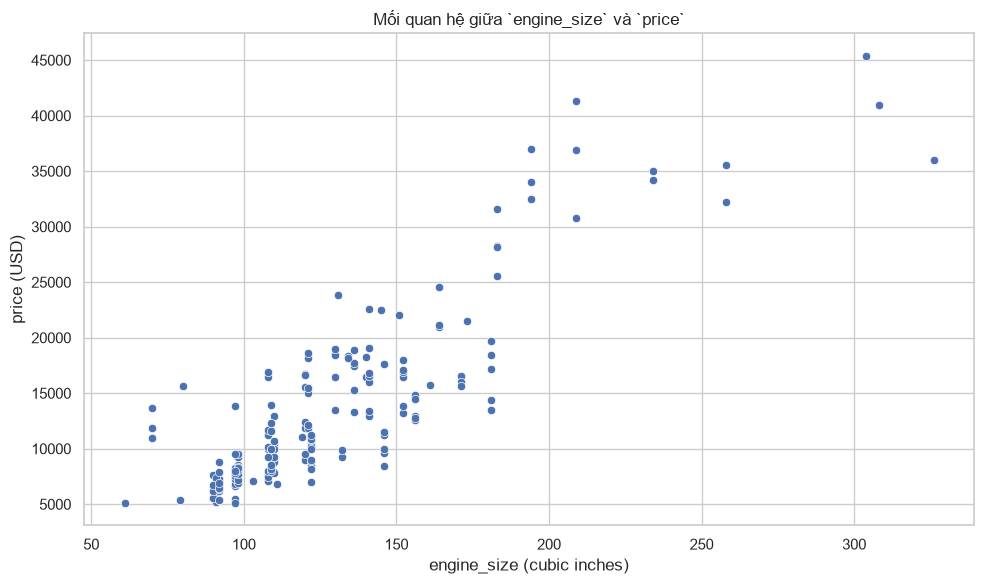

In [109]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_clean, x="engine_size", y="price")

plt.title("Mối quan hệ giữa `engine_size` và `price`")
plt.xlabel("engine_size (cubic inches)")
plt.ylabel("price (USD)")

plt.tight_layout()
plt.show()

**Nhận xét:** 
khi `engine_size` càng lớn thì `price` có xu hướng tăng, cho thấy mối tương quan tuyến tính thuận. Các mẫu xe có `engine_size` từ 60 đến 150 cubic inches, dữ liệu tập trung dày đặc với mức giá dưới 20000 USD.

## M2.5 Các feature numeric tương quan ra sao?

1. **Câu hỏi**: các `numeric_features` trong bộ dữ liệu có mối quan hệ như thế nào?
2. **Biểu đồ phù hợp**: correlation heatmap.

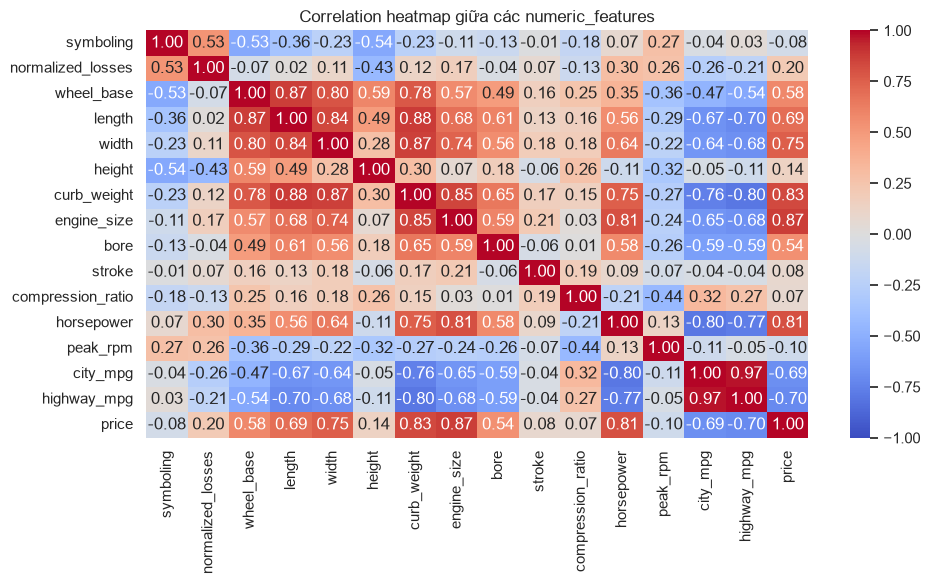

In [110]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10,6))

corr_matrix = df_clean[NUMERIC_COLUMNS].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation heatmap giữa các numeric_features")

plt.tight_layout()
plt.show()

**Nhận xét:** `city_mpg` và `highway_mpg` tương quan dương mạnh mẽ nhất (0.97). `highway_pmg`và `curb_weight` tương quan âm sâu sắc (-0.8).


## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

1. **Câu hỏi**: `curb_weight` ảnh hưởng thế nào đến `highway_mpg` và `fuel_type` có làm thay đổi mối quan hệ đó?
2. **Biểu đồ phù hợp**: scatterplot.

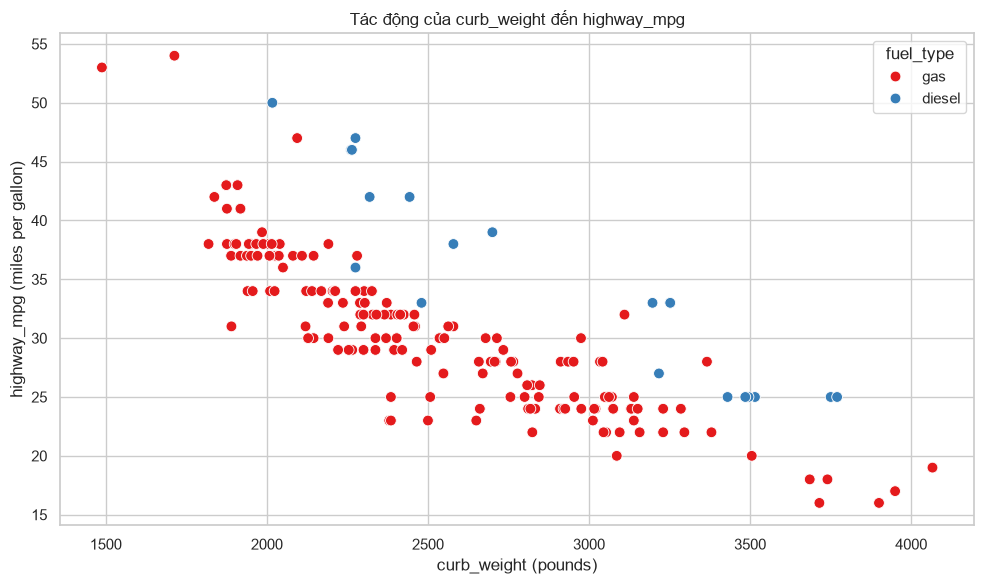

In [111]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_clean, x="curb_weight", y="highway_mpg", hue="fuel_type", palette="Set1", s=60)

plt.title("Tác động của curb_weight đến highway_mpg")
plt.xlabel("curb_weight (pounds)")
plt.ylabel("highway_mpg (miles per gallon)")

plt.tight_layout()
plt.show()

**Nhận xét:** 
scatterplot thể hiện mối tương quan nghịch rõ rệt giữa `curb_weight` và `highway_mpg` (đúng như ma trận tương quan). Ở cùng mức `curb_weight`, động cơ chạy bằng `diesel` có khả năng tiết kiệm nhiên liệu hơn so với động cơ chạy bằng `gas`.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

**Các phát hiện chính**
1. **Giá thị trường**: `price` của các dòng xe trong bộ dữ liệu tập trung ở phân khúc 5000 USD đến 15000 USD (M2.1) với 2 kiểu dáng chiếm số lượng lớn `sedan` và `hatchback` (M2.2).
2. **Sự phân hoá `price` theo `body_style`**: `sedan` có biến động lớn nhất (M2.3).
3. **`engine_size` càng lớn, `price` càng lớn**: (M2.4).
4. **Đánh đổi giữa `curb_weight` và `highway_mpg`**: trọng lượng càng lớn, mức tiết kiệm nhiên liệu càng giảm. Ở cùng mức trọng lượng, ô tô chạy bằng diesel tiết kiệm nhiên liệu hơn chạy bằng gas (M2.6).

**Hạn chế của bộ dữ liệu**
1. **Dữ liệu bị khuyết lớn**: `normalized_losses` thiếu 41 dòng / 205 dòng của bộ dữ liệu gây khó khăn và làm giảm độ tin cậy nếu muốn phân tích sâu hơn về mối quan hệ giữa rủi ro bảo hiểm với các đặc trưng khác.
2. **Kích thước mẫu nhỏ**: bộ dữ liệu có 205 dòng và dữ liệu từ năm 1985 không phù hợp để dự đoán thị trường ngày nay.

**Ví dụ về correslation không đồng nghĩa causation**: Biểu đồ M2.5 trọng lượng xe (`curb_weight`) và giá xe (`price`) tương quan thuận rất mạnh với nhau (0.83), nhưng việc làm chiếc xe nặng thêm bằng cách thêm sắt thép không phải là nguyên nhân khiến xe đắt hơn. Biến ẩn thực tế ở đây là "phân khúc xe": các dòng xe đắt tiền, cao cấp thường được trang bị động cơ lớn hơn, nhiều công nghệ an toàn và nội thất phức tạp hơn, từ đó vô tình làm tăng khối lượng tổng thể của xe.

**Câu hỏi phân tích tiếp theo**: Liệu chúng ta có thể kết hợp các đặc trưng phân loại (Categorical features) như hãng xe (`make`), loại hệ thống nhiên liệu (`fuel_system`) và hệ dẫn động (`drive_wheels`) cùng với các đặc trưng số để xây dựng một mô hình Học máy (Machine Learning) dự đoán chính xác giá xe ô tô?